# EDA — Airline Passenger Satisfaction
Fase 2 del proyecto. Análisis exploratorio del dataset elegido en la Fase 1.

## 1. Carga de datos

In [1]:
import os
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import spearmanr, chi2_contingency

sns.set_style('whitegrid')

path = kagglehub.dataset_download("teejmahal20/airline-passenger-satisfaction")
df_train = pd.read_csv(os.path.join(path, "train.csv"))
df_test = pd.read_csv(os.path.join(path, "test.csv"))
df = pd.concat([df_train, df_test], ignore_index=True)

print(df.shape)
df.head()

(129880, 25)


,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


## 2. Limpieza inicial

Antes de empezar el análisis revisamos la estructura del dataframe para detectar cosas raras.

In [2]:
print(df.info())
print("\nColumnas:", list(df.columns))

<class 'pandas.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         129880 non-null  int64  
 1   id                                 129880 non-null  int64  
 2   Gender                             129880 non-null  str    
 3   Customer Type                      129880 non-null  str    
 4   Age                                129880 non-null  int64  
 5   Type of Travel                     129880 non-null  str    
 6   Class                              129880 non-null  str    
 7   Flight Distance                    129880 non-null  int64  
 8   Inflight wifi service              129880 non-null  int64  
 9   Departure/Arrival time convenient  129880 non-null  int64  
 10  Ease of Online booking             129880 non-null  int64  
 11  Gate location                      129880 non-null

Aparece una columna `Unnamed: 0` que no está en el diccionario de variables. La revisamos antes de decidir qué hacer:

In [3]:
print(df['Unnamed: 0'].head(10))
print(df_train['Unnamed: 0'].equals(df_train.index.to_series()))
print(df_test['Unnamed: 0'].equals(df_test.index.to_series()))

0    0
1    1
2    2
3    3
4    4
5    5
6    6
7    7
8    8
9    9
Name: Unnamed: 0, dtype: int64
True
True


Es el índice original de cada archivo (train y test), y al unirlos ya no significa nada. La quitamos.

In [4]:
df = df.drop(columns=['Unnamed: 0'])
print(df.shape)

(129880, 24)


## 3. Valores faltantes

In [5]:
faltantes = df.isnull().sum()
faltantes_pct = (faltantes / len(df) * 100).round(2)
resumen_faltantes = pd.DataFrame({'faltantes': faltantes, 'porcentaje': faltantes_pct})
print(resumen_faltantes[resumen_faltantes['faltantes'] > 0])

                          faltantes  porcentaje
Arrival Delay in Minutes        393         0.3


Solo `Arrival Delay in Minutes` tiene datos faltantes: 393 (0.3% del total). Antes de imputar, comparamos media y mediana para decidir con cuál rellenar:

In [6]:
print("Media:", df['Arrival Delay in Minutes'].mean())
print("Mediana:", df['Arrival Delay in Minutes'].median())
print("% de vuelos sin demora de llegada:", (df['Arrival Delay in Minutes'] == 0).mean() * 100)

Media: 15.09112883918849
Mediana: 0.0
% de vuelos sin demora de llegada: 56.015552817985835


La mediana es 0 y más de la mitad de los vuelos (56.0%) no tiene demora. La media (15) está inflada por los pocos vuelos con demoras muy largas. Por eso rellenamos con la mediana y no con la media, así no metemos un valor que no representa a la mayoría.

In [7]:
df['Arrival Delay in Minutes'] = df['Arrival Delay in Minutes'].fillna(df['Arrival Delay in Minutes'].median())
print("Faltantes restantes:", df.isnull().sum().sum())

Faltantes restantes: 0


### Faltantes ocultos: los ceros en las calificaciones

El `isnull()` solo encuentra los NaN, pero hay otro tipo de faltante que no aparece ahí. Las 14 preguntas de la encuesta se califican de 1 a 5, y según la descripción del dataset el **0 significa "no aplica / no respondió"**. O sea que un 0 no es una nota baja, es una respuesta que no existe.

Contamos cuántos ceros tiene cada pregunta:

In [8]:
calificaciones = ['Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking',
                  'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
                  'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling',
                  'Checkin service', 'Inflight service', 'Cleanliness']

ceros = (df[calificaciones] == 0).sum()
ceros_pct = (ceros / len(df) * 100).round(2)
resumen_ceros = pd.DataFrame({'ceros': ceros, 'porcentaje': ceros_pct}).sort_values('ceros', ascending=False)
print(resumen_ceros)
print("\nFilas con al menos un 0:", (df[calificaciones] == 0).any(axis=1).sum())

                                   ceros  porcentaje
Departure/Arrival time convenient   6681        5.14
Ease of Online booking              5682        4.37
Inflight wifi service               3916        3.02
Online boarding                     3080        2.37
Leg room service                     598        0.46
Food and drink                       132        0.10
Inflight entertainment                18        0.01
Cleanliness                           14        0.01
On-board service                       5        0.00
Inflight service                       5        0.00
Gate location                          1        0.00
Seat comfort                           1        0.00
Checkin service                        1        0.00
Baggage handling                       0        0.00

Filas con al menos un 0: 10313


Hay más faltantes ocultos (10,313 filas con al menos un 0) que faltantes "normales" (393). Se concentran en cuatro preguntas: `Departure/Arrival time convenient` (5.1%), `Ease of Online booking` (4.4%), `Inflight wifi service` (3.0%) y `Online boarding` (2.4%). En el resto son casos aislados.

Antes de decidir qué hacer con ellos, revisamos si los pasajeros que respondieron 0 se parecen al resto o no. Comparamos el % de satisfechos entre quienes pusieron 0 y el total:

In [9]:
print(f"% satisfechos en todo el dataset: {(df['satisfaction'] == 'satisfied').mean() * 100:.1f}%\n")
for col in resumen_ceros[resumen_ceros['ceros'] > 100].index:
    pct_sat = (df.loc[df[col] == 0, 'satisfaction'] == 'satisfied').mean() * 100
    print(f"{col}: {pct_sat:.1f}% satisfechos entre los que respondieron 0")

% satisfechos en todo el dataset: 43.4%

Departure/Arrival time convenient: 48.1% satisfechos entre los que respondieron 0
Ease of Online booking: 66.6% satisfechos entre los que respondieron 0
Inflight wifi service: 99.7% satisfechos entre los que respondieron 0
Online boarding: 56.5% satisfechos entre los que respondieron 0
Leg room service: 34.4% satisfechos entre los que respondieron 0
Food and drink: 41.7% satisfechos entre los que respondieron 0


Los ceros **no son aleatorios**. El caso más claro es el wifi: el 99.7% de quienes pusieron 0 están satisfechos, contra el 43.4% general. `Ease of Online booking` también se aleja bastante (66.6%). Probablemente son pasajeros que no usaron ese servicio (por ejemplo, vuelos sin wifi), y ese grupo en particular termina más satisfecho.

**Decisión:** no los reemplazamos por la mediana ni los tratamos como una nota. Si imputamos, se pierde justamente esa información. Lo que proponemos es:
- Para el análisis de las calificaciones (medias, correlaciones), tratar el 0 como NaN, para que no baje los promedios como si fuera una nota muy mala.
- Para un modelo más adelante, crear una variable indicadora (`no_respondio_wifi`, etc.) en las 4 preguntas con más ceros, porque el hecho de no responder ya dice algo sobre la satisfacción.

Por ahora no modificamos `df`: dejamos los ceros como están y los tenemos en cuenta en cada análisis.

### Duplicados

Por último revisamos si hay filas repetidas, y si algún `id` de pasajero aparece más de una vez (podría pasar al unir train y test):

In [10]:
print("Filas duplicadas:", df.duplicated().sum())
print("IDs repetidos:", df['id'].duplicated().sum())
print("Filas duplicadas sin contar el id:", df.drop(columns='id').duplicated().sum())

Filas duplicadas: 0
IDs repetidos: 0
Filas duplicadas sin contar el id: 0


No hay duplicados de ningún tipo: ni filas completas, ni `id` repetidos, ni pasajeros con exactamente las mismas respuestas bajo otro `id`. Cada fila es un pasajero distinto y train y test no se solapan.

## 4. Outliers

Primero vemos qué columnas numéricas hay en total, para no analizar outliers "a ojo":

In [11]:
todas_columnas_numericas = df.select_dtypes(include=np.number).columns.tolist()
print(todas_columnas_numericas)

['id', 'Age', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']


In [12]:
df[todas_columnas_numericas].describe()

,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000
mean,64940.500000,39.427957,1190.316392,2.728696,3.057599,2.756876,2.976925,3.204774,3.252633,3.441361,3.358077,3.383023,3.350878,3.632114,3.306267,3.642193,3.286326,14.713713,15.045465
std,37493.270818,15.119360,997.452477,1.329340,1.526741,1.401740,1.278520,1.329933,1.350719,1.319289,1.334049,1.287099,1.316252,1.180025,1.266185,1.176669,1.313682,38.071126,38.416353
min,1.000000,7.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,32470.750000,27.000000,414.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,64940.500000,40.000000,844.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000,0.000000,0.000000
75%,97410.250000,51.000000,1744.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000
max,129880.000000,85.000000,4983.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1592.000000,1584.000000


Con el `describe()` de arriba separamos las columnas en tres grupos:

- `id`: es solo un número de pasajero, no sirve para análisis.
- Las columnas de calificación (wifi, comida, comodidad del asiento, etc.) van de 0 a 5. Son escalas de encuesta, no variables continuas — no tiene sentido buscarles "outliers" (un 5 no es un valor raro, es la nota máxima).
- Las que sí son continuas de verdad: `Age`, `Flight Distance`, `Departure Delay in Minutes` y `Arrival Delay in Minutes`. En estas sí vale la pena buscar atípicos.

Nos quedamos con este último grupo para el análisis de outliers.

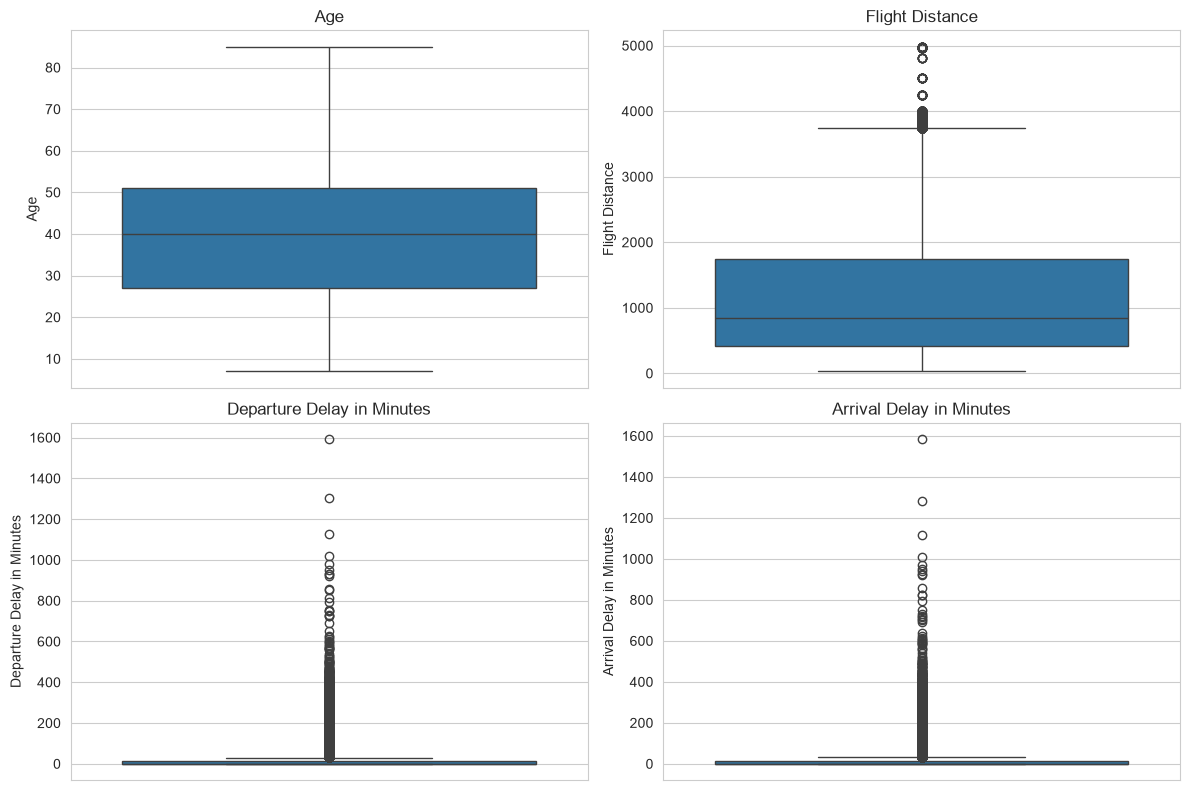

In [13]:
columnas_numericas = ['Age', 'Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), columnas_numericas):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

`Age` no tiene outliers. `Flight Distance` tiene algunos, moderados. Los dos delays tienen muchísimos puntos fuera de la caja — algo esperado, ya que la mayoría de vuelos no tiene demora pero hay una cola de vuelos con demoras grandes.

Ahora lo calculamos con el método IQR para tener un número exacto, no solo la lectura visual:

In [14]:
def detectar_outliers_iqr(serie):
    Q1, Q3 = serie.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lim_inf, lim_sup = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    outliers = (serie < lim_inf) | (serie > lim_sup)
    return outliers.sum(), lim_inf, lim_sup

for col in columnas_numericas:
    n_outliers, li, ls = detectar_outliers_iqr(df[col])
    pct = (n_outliers / len(df)) * 100
    print(f"{col}: {n_outliers} outliers ({pct:.2f}%) — rango válido [{li:.1f}, {ls:.1f}]")

Age: 0 outliers (0.00%) — rango válido [-9.0, 87.0]
Flight Distance: 2855 outliers (2.20%) — rango válido [-1581.0, 3739.0]
Departure Delay in Minutes: 18098 outliers (13.93%) — rango válido [-18.0, 30.0]
Arrival Delay in Minutes: 17492 outliers (13.47%) — rango válido [-19.5, 32.5]


Los delays salen con 13-14% de "outliers", un porcentaje demasiado alto para tratarlos como errores. Además, el límite que calcula el IQR (30 minutos) es poco realista para vuelos: una demora de una hora pasa todo el tiempo en la vida real, no es un dato dañado.

Por eso no eliminamos estos outliers. Son vuelos con demoras reales, y de hecho son justo el tipo de caso que puede interesar analizar más adelante (¿la demora afecta la satisfacción?).

### Comparación con z-score

El IQR no es el único método. El z-score mide a cuántas desviaciones estándar de la media está cada valor, y se suele marcar como atípico lo que tenga |z| > 3. Lo calculamos en las mismas 4 columnas para comparar:

In [15]:
comparacion = []
for col in columnas_numericas:
    z = np.abs(stats.zscore(df[col]))
    n_iqr, _, _ = detectar_outliers_iqr(df[col])
    comparacion.append({
        'columna': col,
        'outliers_IQR': n_iqr,
        'outliers_z>3': (z > 3).sum(),
        '%_IQR': round(n_iqr / len(df) * 100, 2),
        '%_z>3': round((z > 3).sum() / len(df) * 100, 2),
        'limite_z (media + 3*std)': round(df[col].mean() + 3 * df[col].std(), 1),
    })
pd.DataFrame(comparacion).set_index('columna')

,outliers_IQR,outliers_z>3,%_IQR,%_z>3,limite_z (media + 3*std)
columna,,,,,
Age,0,25,0.00,0.02,84.8
Flight Distance,2855,78,2.20,0.06,4182.7
Departure Delay in Minutes,18098,2748,13.93,2.12,128.9
Arrival Delay in Minutes,17492,2742,13.47,2.11,130.3


Los dos métodos dan resultados muy distintos:

- **Delays:** el IQR marca ~14% y el z-score solo ~2.1%. El IQR pone el límite en 30 minutos porque la mitad de los vuelos tiene demora 0 y la caja queda muy estrecha. El z-score lo pone en ~130 minutos (2 horas), un criterio más razonable para una demora "fuera de lo normal".
- **Flight Distance:** 2,855 por IQR contra 78 por z-score. Solo los vuelos de más de ~4,180 millas quedan fuera con z.
- **Age:** el IQR no marca ninguno y el z-score marca 25 (pasajeros de 85 años). Son edades posibles, no errores.

Ninguno de los dos métodos es perfecto aquí: el z-score asume una distribución más o menos normal y usa la media y la desviación estándar, que también se inflan con la cola. Pero los dos llevan a la misma conclusión: los valores extremos son pocos, son posibles en la vida real y no hay por qué eliminarlos.

### Diagramas de dispersión

Para ver los outliers en dos dimensiones y cómo se relacionan con la satisfacción, graficamos una muestra de 10,000 pasajeros (con el dataset completo los puntos se tapan entre sí):

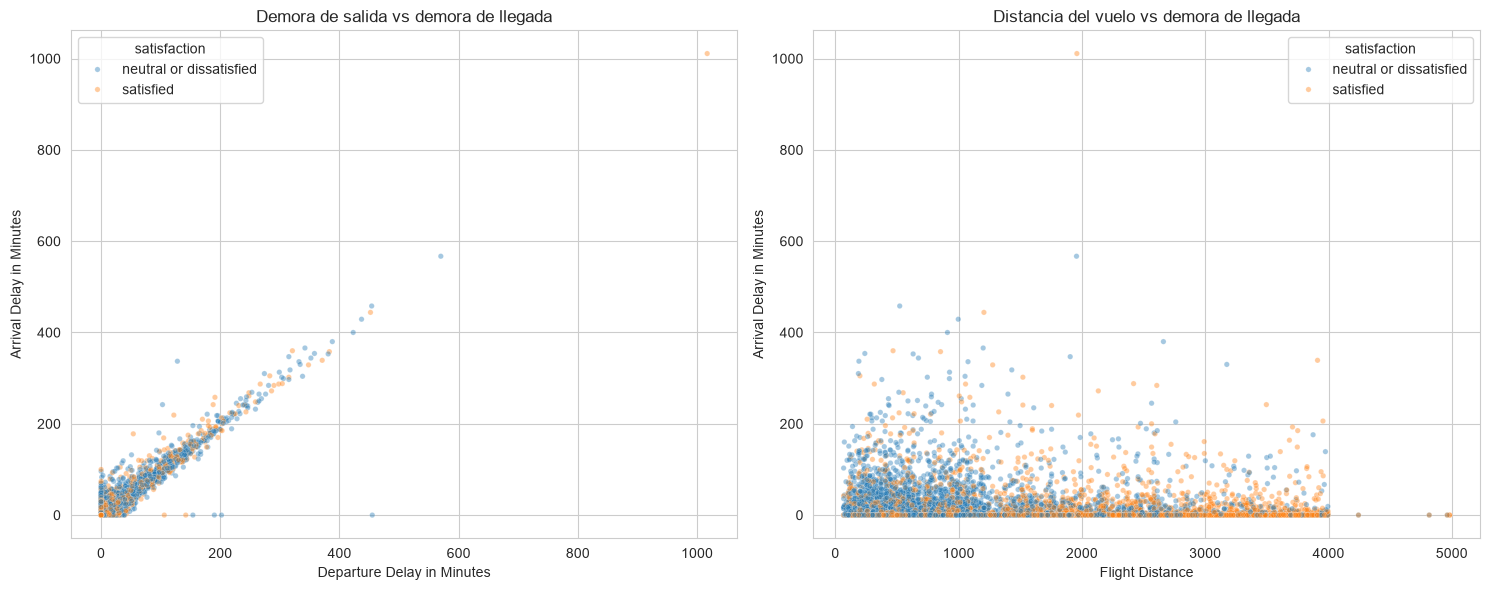

In [16]:
muestra = df.sample(10000, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.scatterplot(data=muestra, x='Departure Delay in Minutes', y='Arrival Delay in Minutes',
                hue='satisfaction', alpha=0.4, s=15, ax=axes[0])
axes[0].set_title('Demora de salida vs demora de llegada')

sns.scatterplot(data=muestra, x='Flight Distance', y='Arrival Delay in Minutes',
                hue='satisfaction', alpha=0.4, s=15, ax=axes[1])
axes[1].set_title('Distancia del vuelo vs demora de llegada')
plt.tight_layout()
plt.show()

- **Salida vs llegada:** los puntos forman casi una línea recta de pendiente 1. El avión que sale tarde llega tarde en casi la misma cantidad de minutos (la diferencia tiene mediana 0). Por eso Pearson da 0.96: los outliers no rompen la relación, al contrario, están justo sobre la línea y la refuerzan. Las dos variables miden casi lo mismo, lo cual es importante para la Fase 3 (son redundantes).
- **Distancia vs llegada:** no hay ninguna forma, es una nube. La correlación es prácticamente 0 (Spearman ≈ 0.00), así que los vuelos largos no se demoran más.
- **Satisfacción:** en los dos gráficos los colores están mezclados, incluso en las demoras grandes. La demora sola no separa a satisfechos de insatisfechos. En cambio, en el segundo gráfico se ve que los satisfechos se concentran más a la derecha (vuelos largos): la mediana de distancia es 1,249 millas en satisfechos contra 674 en insatisfechos.

**Un detalle que muestra el gráfico:** hay algunos puntos sobre el eje horizontal, con mucha demora de salida pero 0 de llegada, que se salen de la línea. Los revisamos:

In [17]:
imputados = df_train['Arrival Delay in Minutes'].isna().tolist() + df_test['Arrival Delay in Minutes'].isna().tolist()
imputados = pd.Series(imputados, index=df.index)

raros = (df['Departure Delay in Minutes'] > 60) & (df['Arrival Delay in Minutes'] == 0)
print("Vuelos con más de 60 min de demora de salida y 0 de llegada:", raros.sum())
print("De esos, cuántos eran faltantes imputados con la mediana:", (raros & imputados).sum())

Vuelos con más de 60 min de demora de salida y 0 de llegada: 86
De esos, cuántos eran faltantes imputados con la mediana: 86


Todos esos puntos raros son filas donde `Arrival Delay in Minutes` venía vacía y la rellenamos con la mediana (0). La mediana era mejor opción que la media, pero el gráfico muestra que había una mejor: como la demora de llegada es casi igual a la de salida (correlación 0.96), se podría haber rellenado cada faltante con su propia `Departure Delay in Minutes`. Son solo 393 filas (0.3%), así que no cambia las conclusiones, pero lo dejamos anotado como mejora para el preprocesamiento.

## 5. Distribución de las variables numéricas

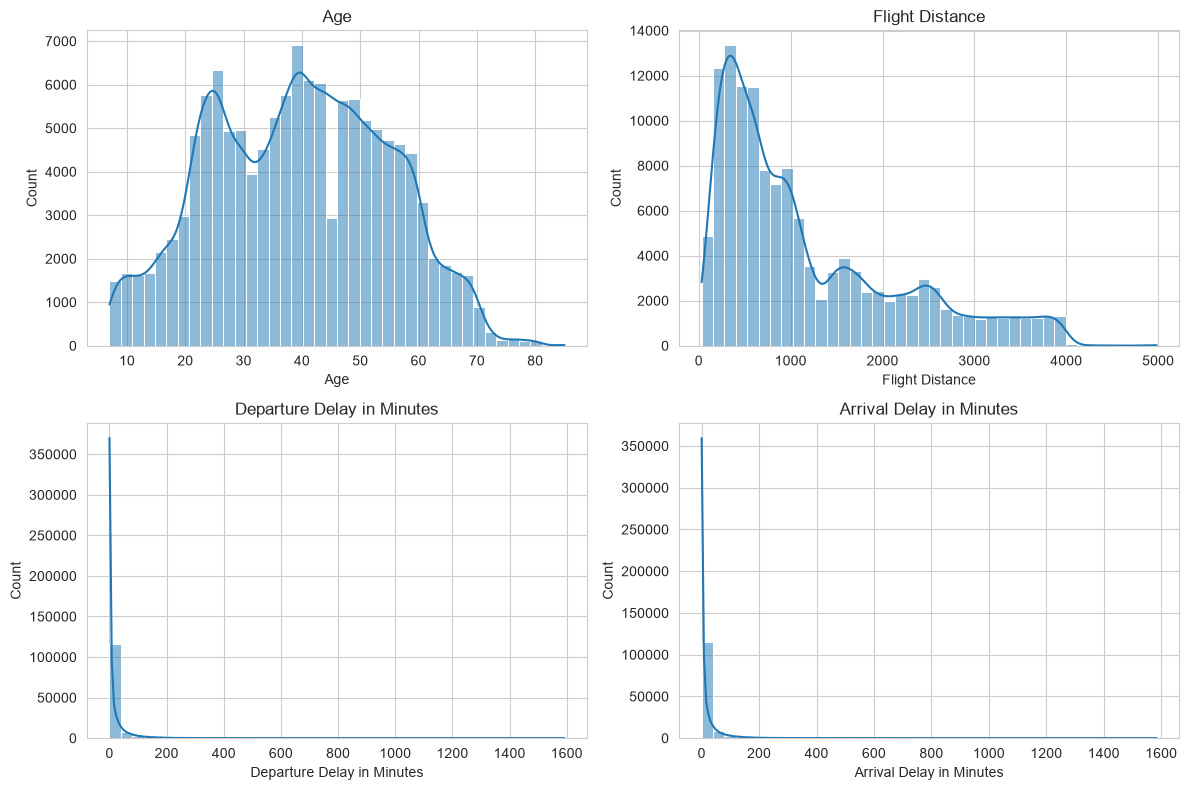

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), columnas_numericas):
    sns.histplot(df[col], kde=True, ax=ax, bins=40)
    ax.set_title(col)
plt.tight_layout()
plt.show()

`Age` tiene dos picos (uno cerca de los 25 y otro cerca de los 40), pero es bastante simétrica en general. `Flight Distance` tiene cola hacia la derecha (más vuelos cortos que largos). Los delays son casi todo ceros con una cola larguísima.

Confirmamos esto con el coeficiente de asimetría (skewness):

In [19]:
for col in columnas_numericas:
    print(f"{col}: skewness = {df[col].skew():.2f}")

Age: skewness = -0.00
Flight Distance: skewness = 1.11
Departure Delay in Minutes: skewness = 6.82
Arrival Delay in Minutes: skewness = 6.68


`Age` sale casi en 0 (simétrica), `Flight Distance` en 1.11 (sesgo moderado), y los dos delays por encima de 6.5 — un sesgo extremo. Cualquier valor de skewness fuera de ±1 ya se considera sesgado, así que los delays están muy lejos de una distribución normal. Esto confirma por qué el IQR no funcionó bien con ellos: ese método asume datos más simétricos.

Si más adelante se necesitara usar estas variables en un modelo, se podría aplicar una transformación logarítmica para suavizar ese sesgo.

Lo comprobamos: comparamos los histogramas de los delays antes y después de aplicar `np.log1p` (log(1 + x), que funciona con los ceros porque log1p(0) = 0):

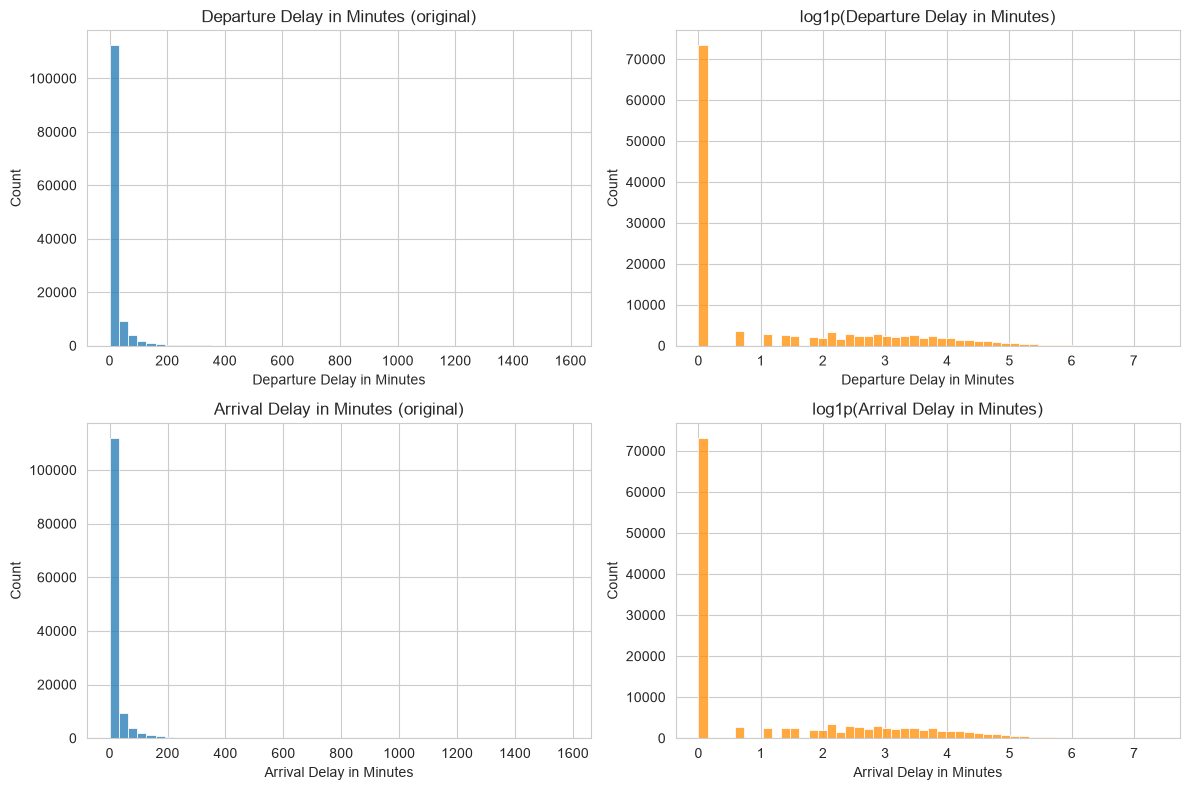

Departure Delay in Minutes: skewness original = 6.82 | con log1p = 0.92
Arrival Delay in Minutes: skewness original = 6.68 | con log1p = 0.88


In [20]:
delays = ['Departure Delay in Minutes', 'Arrival Delay in Minutes']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for fila, col in enumerate(delays):
    sns.histplot(df[col], bins=50, ax=axes[fila, 0])
    axes[fila, 0].set_title(f"{col} (original)")
    sns.histplot(np.log1p(df[col]), bins=50, ax=axes[fila, 1], color='darkorange')
    axes[fila, 1].set_title(f"log1p({col})")
plt.tight_layout()
plt.show()

for col in delays:
    print(f"{col}: skewness original = {df[col].skew():.2f} | con log1p = {np.log1p(df[col]).skew():.2f}")

Con `log1p` la asimetría baja de ~6.8 a menos de 1, y la cola larga se comprime: una demora de 1,500 minutos ya no queda a cientos de unidades del resto. No queda una campana perfecta, porque el 56% de los vuelos tiene demora 0 y eso forma una barra muy alta en el cero que ninguna transformación puede repartir. Aun así, es suficiente para que los delays no dominen métodos sensibles a la escala como el PCA. Por eso en la Fase 3 se aplica `log1p` antes de escalar.

## 6. Variables categóricas

In [21]:
columnas_categoricas = df.select_dtypes(include=['object', 'str']).columns.tolist()
print(columnas_categoricas)

['Gender', 'Customer Type', 'Type of Travel', 'Class', 'satisfaction']


In [22]:
for col in columnas_categoricas:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(normalize=True).round(3) * 100)


--- Gender ---
Gender
Female    50.7
Male      49.3
Name: proportion, dtype: float64

--- Customer Type ---
Customer Type
Loyal Customer       81.7
disloyal Customer    18.3
Name: proportion, dtype: float64

--- Type of Travel ---
Type of Travel
Business travel    69.1
Personal Travel    30.9
Name: proportion, dtype: float64

--- Class ---
Class
Business    47.9
Eco         44.9
Eco Plus     7.2
Name: proportion, dtype: float64

--- satisfaction ---
satisfaction
neutral or dissatisfied    56.6
satisfied                  43.4
Name: proportion, dtype: float64


- `Gender`: casi mitad y mitad.
- `Customer Type`: 82% son clientes leales, solo 18% no leales.
- `Type of Travel`: 69% viaja por trabajo, 31% por motivos personales.
- `Class`: Business y Eco están parejos (48% y 45%), Eco Plus es minoría (7%).
- `satisfaction` (la variable que queremos explicar): 57% no satisfechos, 43% satisfechos. No es un desbalance grave.

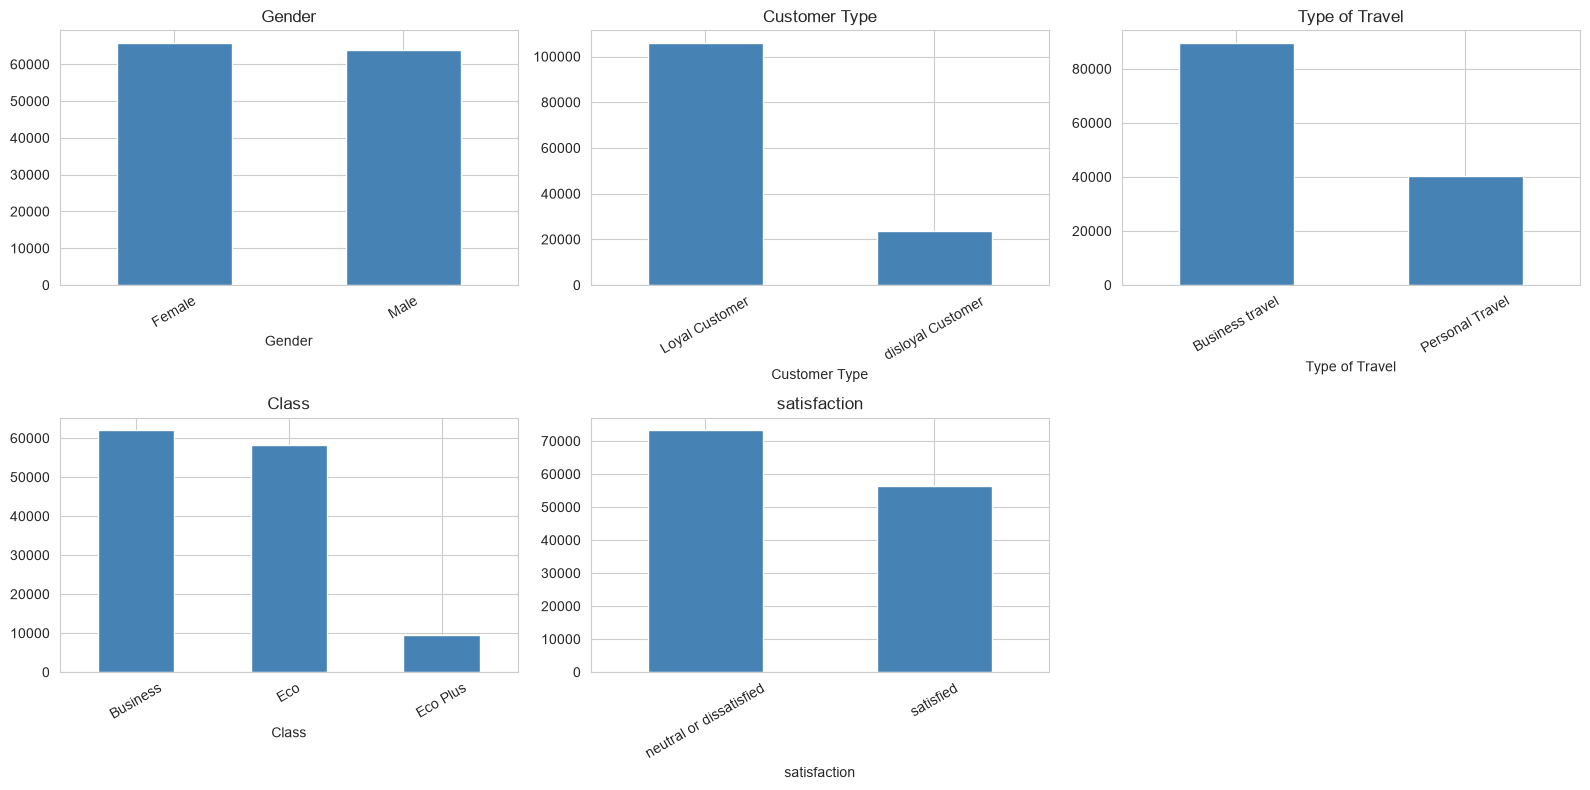

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flatten(), columnas_categoricas):
    df[col].value_counts().plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=30)
axes.flatten()[-1].axis('off')
plt.tight_layout()
plt.show()

### Las 14 calificaciones de la encuesta

En la sección de outliers dejamos de lado las calificaciones porque no son continuas, pero son 14 de las 22 variables, así que hay que analizarlas. Como decidimos en la sección de faltantes, para calcular medias y correlaciones tratamos el 0 como NaN (no respondió), para que no baje los promedios como si fuera una nota.

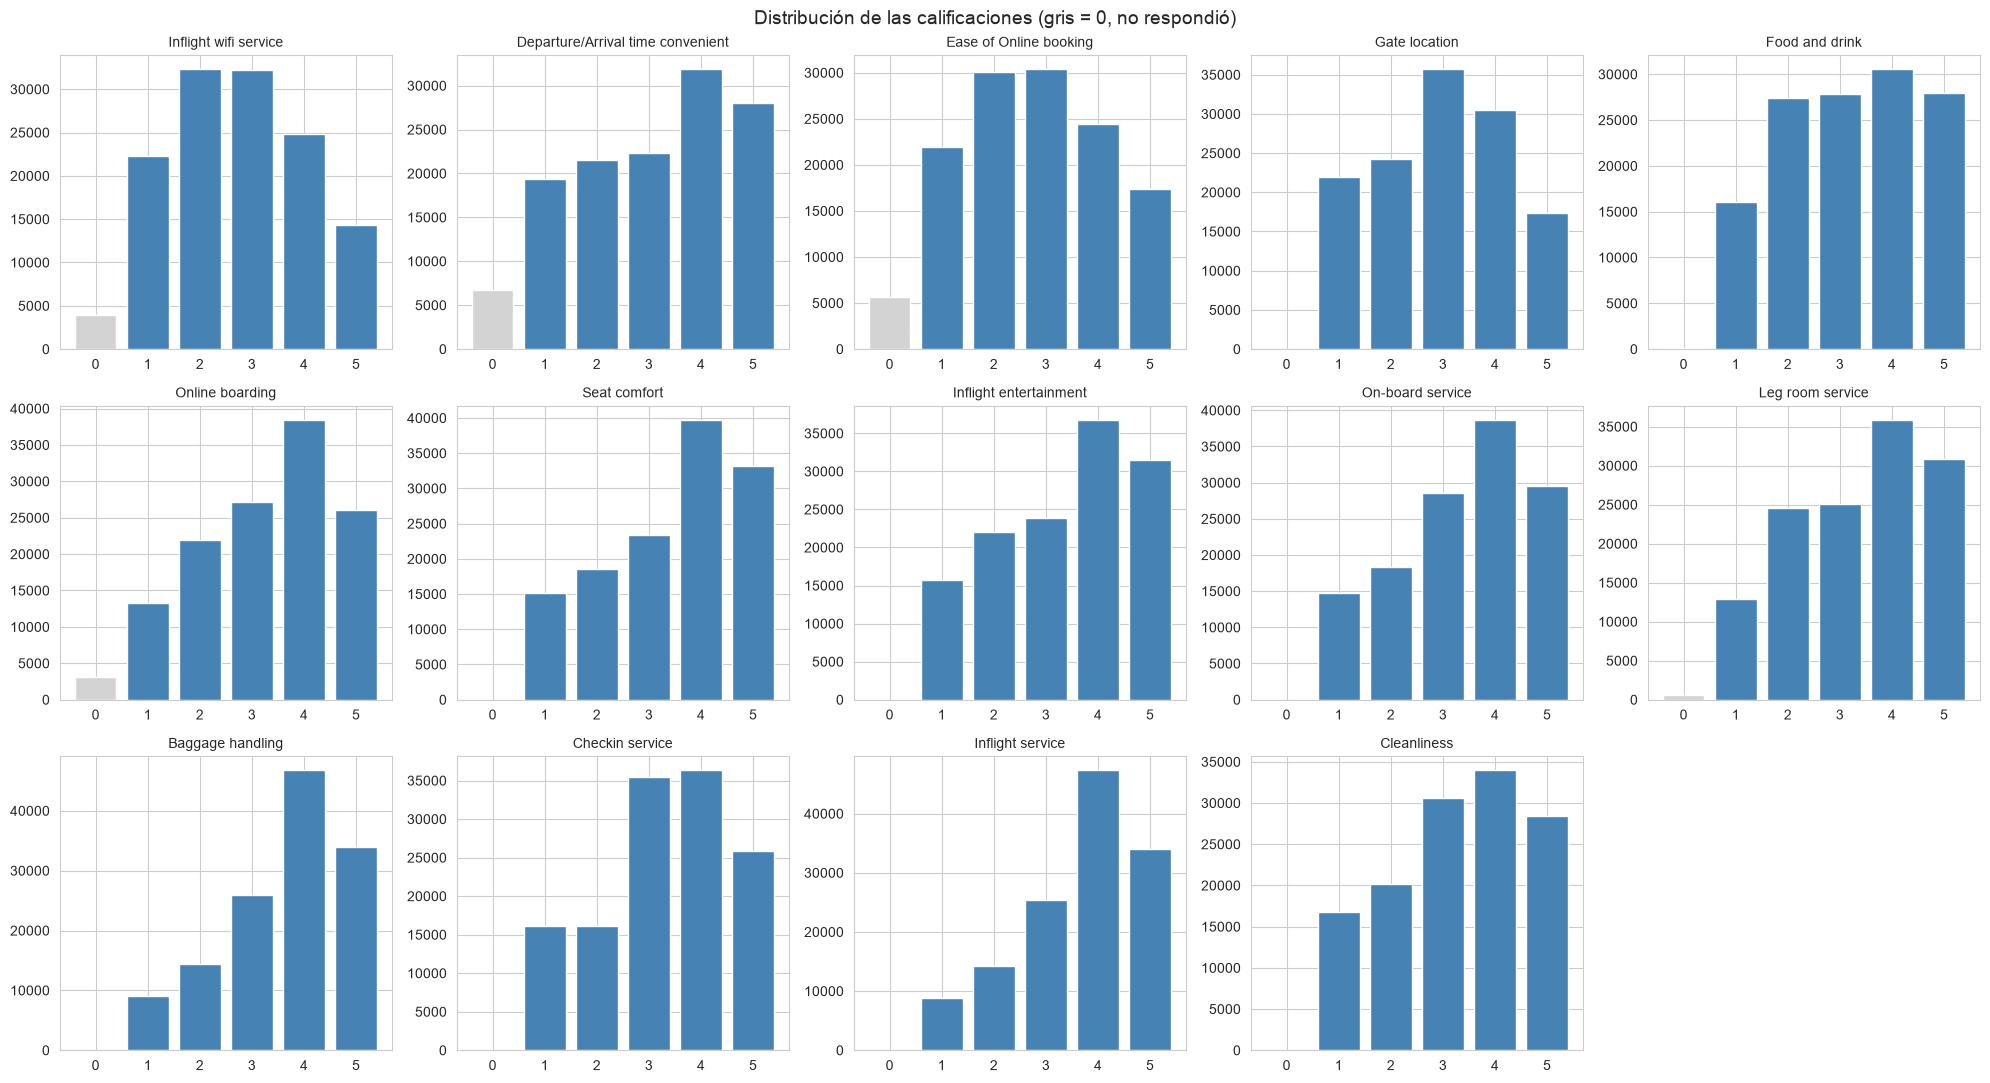

In [24]:
calif_sin_ceros = df[calificaciones].replace(0, np.nan)

fig, axes = plt.subplots(3, 5, figsize=(20, 11))
for ax, col in zip(axes.flatten(), calificaciones):
    conteo = df[col].value_counts().reindex(range(6), fill_value=0)
    colores = ['lightgray'] + ['steelblue'] * 5
    ax.bar(conteo.index, conteo.values, color=colores)
    ax.set_title(col, fontsize=10)
    ax.set_xticks(range(6))
axes.flatten()[-1].axis('off')
plt.suptitle('Distribución de las calificaciones (gris = 0, no respondió)', fontsize=14)
plt.tight_layout()
plt.show()

In [25]:
resumen_calif = pd.DataFrame({
    'media': calif_sin_ceros.mean().round(2),
    'mediana': calif_sin_ceros.median(),
    '% notas 1-2': ((calif_sin_ceros <= 2).sum() / calif_sin_ceros.notna().sum() * 100).round(1),
    '% notas 5': ((calif_sin_ceros == 5).sum() / calif_sin_ceros.notna().sum() * 100).round(1),
}).sort_values('media')
resumen_calif

,media,mediana,% notas 1-2,% notas 5
Inflight wifi service,2.81,3.0,43.4,11.4
Ease of Online booking,2.88,3.0,41.8,14.0
Gate location,2.98,3.0,35.6,13.4
Food and drink,3.21,3.0,33.5,21.5
Departure/Arrival time convenient,3.22,3.0,33.2,22.7
Cleanliness,3.29,3.0,28.4,21.9
Checkin service,3.31,3.0,24.8,19.9
Online boarding,3.33,4.0,27.8,20.5
Inflight entertainment,3.36,4.0,29.0,24.3
Leg room service,3.37,4.0,29.0,23.9


- **Peor calificadas:** `Inflight wifi service` (media 2.81, el 42% le pone 1 o 2), `Ease of Online booking` (2.88) y `Gate location` (2.98). Son las únicas por debajo de 3. Dos de las tres son servicios digitales.
- **Mejor calificadas:** `Inflight service` (3.64) y `Baggage handling` (3.63), con apenas ~18% de notas bajas y más de 26% de 5.
- En general las notas son intermedias: todas las medias están entre 2.8 y 3.7 y las medianas son 3 o 4. Ninguna pregunta está claramente "aprobada" o "reprobada".
- Las distribuciones no son iguales entre sí: las del servicio a bordo se cargan hacia el 4 y 5, y las del wifi y la reserva en línea son más planas. Esto se ve mejor en los gráficos que en la media.

## 7. Relación entre variables

### Correlaciones numéricas

Antes de calcular correlaciones, comparamos Pearson contra Spearman en los delays, ya que sabemos que tienen un sesgo fuerte:

In [26]:
for col1, col2 in [('Departure Delay in Minutes', 'Arrival Delay in Minutes'),
                     ('Departure Delay in Minutes', 'Age'),
                     ('Arrival Delay in Minutes', 'Flight Distance')]:
    pearson = df[col1].corr(df[col2])
    spearman, _ = spearmanr(df[col1], df[col2])
    print(f"{col1} vs {col2}: Pearson={pearson:.3f}, Spearman={spearman:.3f}")

Departure Delay in Minutes vs Arrival Delay in Minutes: Pearson=0.959, Spearman=0.737
Departure Delay in Minutes vs Age: Pearson=-0.009, Spearman=-0.009
Arrival Delay in Minutes vs Flight Distance: Pearson=-0.002, Spearman=-0.002


Entre los dos delays, Pearson da 0.96 y Spearman da 0.74 — una diferencia real. Pearson se deja influenciar por los valores extremos y exagera un poco la relación; Spearman, al trabajar con rangos, da un número más realista. En las otras dos comparaciones, donde no hay relación real, da casi lo mismo con cualquiera de los dos métodos.

Con esto en mente, vemos la matriz de correlación completa (incluyendo algunas columnas de calificación):

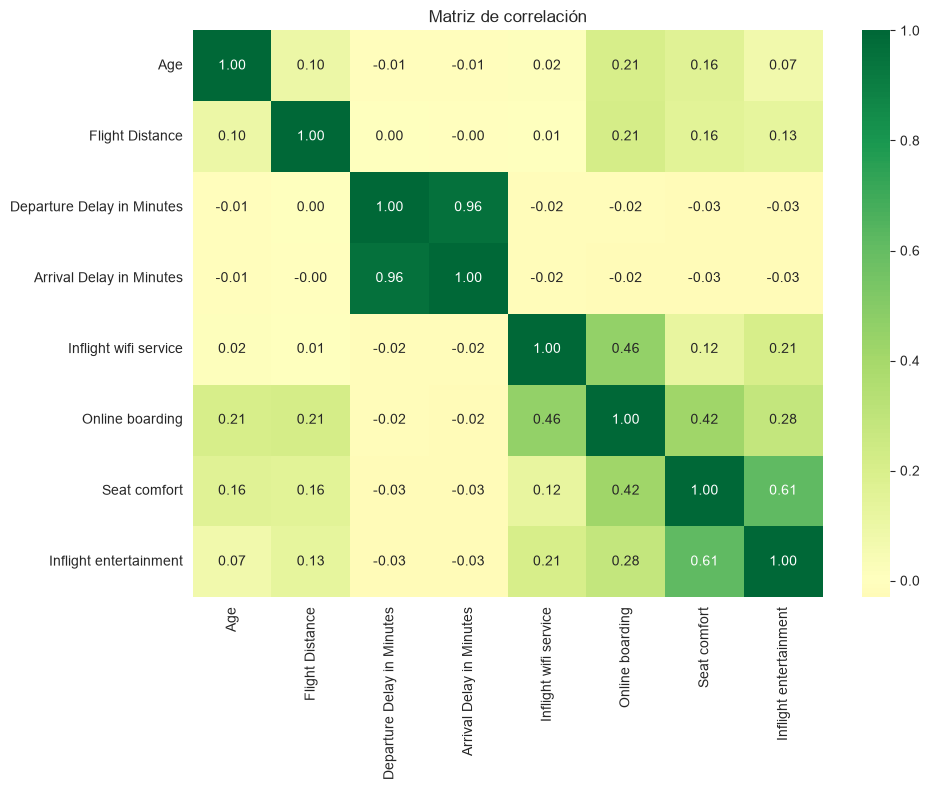

In [27]:
columnas_correlacion = columnas_numericas + ['Inflight wifi service', 'Online boarding', 'Seat comfort', 'Inflight entertainment']

corr = df[columnas_correlacion].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0)
plt.title('Matriz de correlación')
plt.tight_layout()
plt.show()

Lo más fuerte es la relación entre los dos delays (0.96, ya la vimos) y entre `Seat comfort` e `Inflight entertainment` (0.61). Los delays no se relacionan con casi nada más.

### Tablas cruzadas con satisfacción

Ahora cruzamos las categóricas contra `satisfaction`, para ver cuáles parecen influir de verdad:

In [28]:
for col in ['Gender', 'Customer Type', 'Type of Travel', 'Class']:
    print(f"\n--- {col} vs satisfaction ---")
    tabla = pd.crosstab(df[col], df['satisfaction'], normalize='index') * 100
    print(tabla.round(1))


--- Gender vs satisfaction ---
satisfaction  neutral or dissatisfied  satisfied
Gender                                          
Female                           57.1       42.9
Male                             56.0       44.0

--- Customer Type vs satisfaction ---
satisfaction       neutral or dissatisfied  satisfied
Customer Type                                        
Loyal Customer                        52.2       47.8
disloyal Customer                     76.0       24.0

--- Type of Travel vs satisfaction ---


satisfaction     neutral or dissatisfied  satisfied
Type of Travel                                     
Business travel                     41.6       58.4
Personal Travel                     89.9       10.1

--- Class vs satisfaction ---
satisfaction  neutral or dissatisfied  satisfied
Class                                           
Business                         30.6       69.4
Eco                              81.2       18.8
Eco Plus                         75.4       24.6


`Gender` no marca casi diferencia (57% vs 56%). Las otras tres sí:

- `Customer Type`: los leales están satisfechos el 48% de las veces, los no leales solo el 24%.
- `Type of Travel`: es la más marcada de todas — negocios 58% satisfechos, personal solo 10%.
- `Class`: Business 69% satisfechos, Eco 19%, Eco Plus 25%.

`Type of Travel` y `Class` se mueven muy parecido. Puede que no sean dos efectos separados, sino el mismo fenómeno visto dos veces — lo revisamos:

In [29]:
pd.crosstab(df['Type of Travel'], df['Class'], normalize='index').round(3) * 100

Class,Business,Eco,Eco Plus
Type of Travel,,,
Business travel,66.3,28.2,5.5
Personal Travel,6.7,82.1,11.2


Confirmado: 66% de los que viajan por negocios van en Business, y 82% de los que viajan por motivos personales van en Eco. Están fuertemente ligadas, así que su efecto sobre la satisfacción probablemente se solapa.

### Correlación entre las 14 calificaciones

La matriz de arriba solo incluía 4 calificaciones. Ahora las vemos todas juntas. Usamos **Spearman** y no Pearson porque son escalas ordinales (1 a 5): sabemos que un 4 es mejor que un 3, pero no que la distancia entre 3 y 4 sea igual a la de 4 y 5.

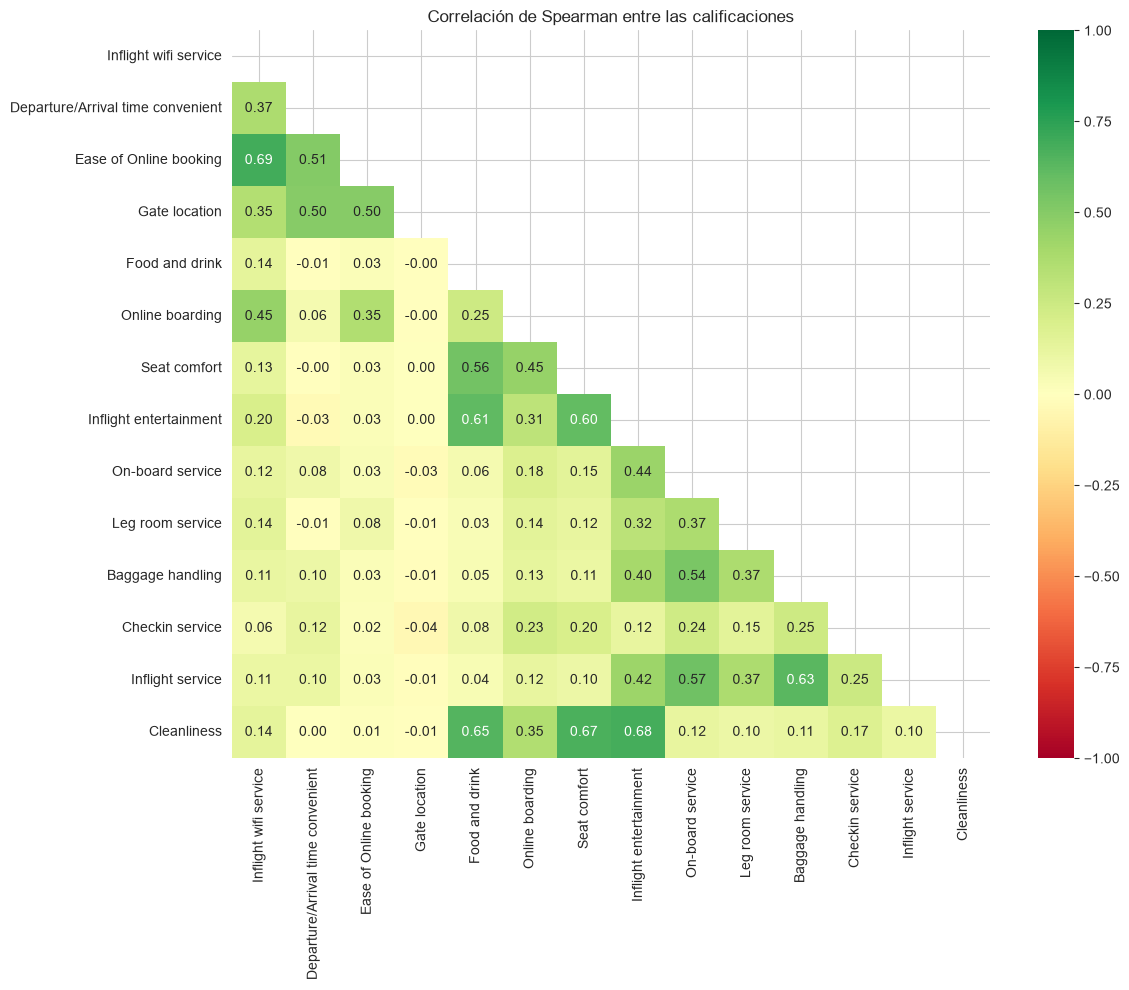

In [30]:
corr_calif = calif_sin_ceros.corr(method='spearman')

plt.figure(figsize=(12, 10))
mascara = np.triu(np.ones_like(corr_calif, dtype=bool))
sns.heatmap(corr_calif, mask=mascara, annot=True, fmt='.2f', cmap='RdYlGn', center=0, vmin=-1, vmax=1)
plt.title('Correlación de Spearman entre las calificaciones')
plt.tight_layout()
plt.show()

Las calificaciones forman **grupos** que se mueven juntos:

- **Servicios digitales y antes del vuelo:** `Inflight wifi service` con `Ease of Online booking` (0.69, la más alta de toda la matriz), y estas dos con `Gate location` y `Departure/Arrival time convenient` (~0.50).
- **Comodidad a bordo:** `Cleanliness`, `Inflight entertainment`, `Seat comfort` y `Food and drink`, todas entre 0.56 y 0.68 entre sí.
- **Atención del personal:** `Baggage handling`, `Inflight service` y `On-board service` (0.54-0.63).

Entre grupos las correlaciones son bajas, y `Gate location` no tiene relación con casi nada fuera de su grupo (~0.00). Esto quiere decir que las 14 preguntas no miden 14 cosas distintas, sino más o menos 3 o 4 aspectos del viaje. Es un buen argumento para usar PCA en la Fase 3: hay redundancia que se puede comprimir.

### Calificaciones vs satisfacción

Esta es probablemente la relación más importante del dataset: ¿qué calificaciones cambian más entre los pasajeros satisfechos y los insatisfechos? Comparamos el promedio de cada pregunta en los dos grupos, ordenadas por la diferencia:

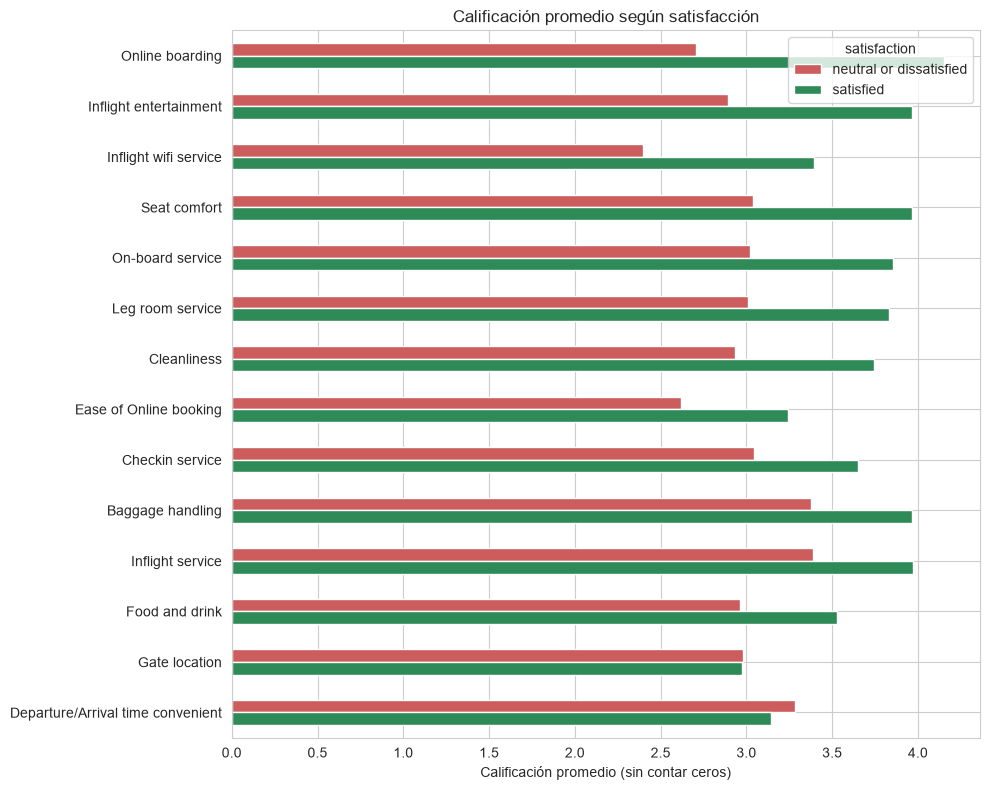

satisfaction,neutral or dissatisfied,satisfied,diferencia
Online boarding,2.71,4.15,1.45
Inflight entertainment,2.89,3.96,1.07
Inflight wifi service,2.40,3.39,0.99
Seat comfort,3.04,3.97,0.93
On-board service,3.02,3.86,0.84
Leg room service,3.01,3.83,0.83
Cleanliness,2.93,3.75,0.81
Ease of Online booking,2.62,3.24,0.63
Checkin service,3.04,3.65,0.61
Baggage handling,3.37,3.97,0.59


In [31]:
medias_por_grupo = calif_sin_ceros.groupby(df['satisfaction']).mean().T
medias_por_grupo['diferencia'] = medias_por_grupo['satisfied'] - medias_por_grupo['neutral or dissatisfied']
medias_por_grupo = medias_por_grupo.sort_values('diferencia', ascending=False)

medias_por_grupo[['neutral or dissatisfied', 'satisfied']].plot(kind='barh', figsize=(10, 8),
                                                                color=['indianred', 'seagreen'])
plt.gca().invert_yaxis()
plt.xlabel('Calificación promedio (sin contar ceros)')
plt.title('Calificación promedio según satisfacción')
plt.legend(title='satisfaction')
plt.tight_layout()
plt.show()

medias_por_grupo.round(2)

- **`Online boarding` es la que más separa**: 4.15 en satisfechos contra 2.71 en insatisfechos, casi 1.5 puntos de diferencia. Le siguen `Inflight entertainment` (+1.07), `Inflight wifi service` (+0.99) y `Seat comfort` (+0.93). Coincide con lo que salió en los loadings del PCA en la Fase 3.
- Todas las demás tienen diferencias de 0.6 a 0.8 puntos: todo suma, pero menos.
- **`Gate location` y `Departure/Arrival time convenient` no marcan ninguna diferencia** (-0.01 y -0.14). La ubicación de la puerta y la conveniencia del horario no explican si el pasajero queda satisfecho. De hecho, los insatisfechos califican el horario un poco mejor.
- El wifi es un caso interesante: es la peor calificada en general, pero también de las que más separan. Como es mala para casi todos, los pocos que la califican bien tienden a estar satisfechos.

### Edad y demoras vs satisfacción

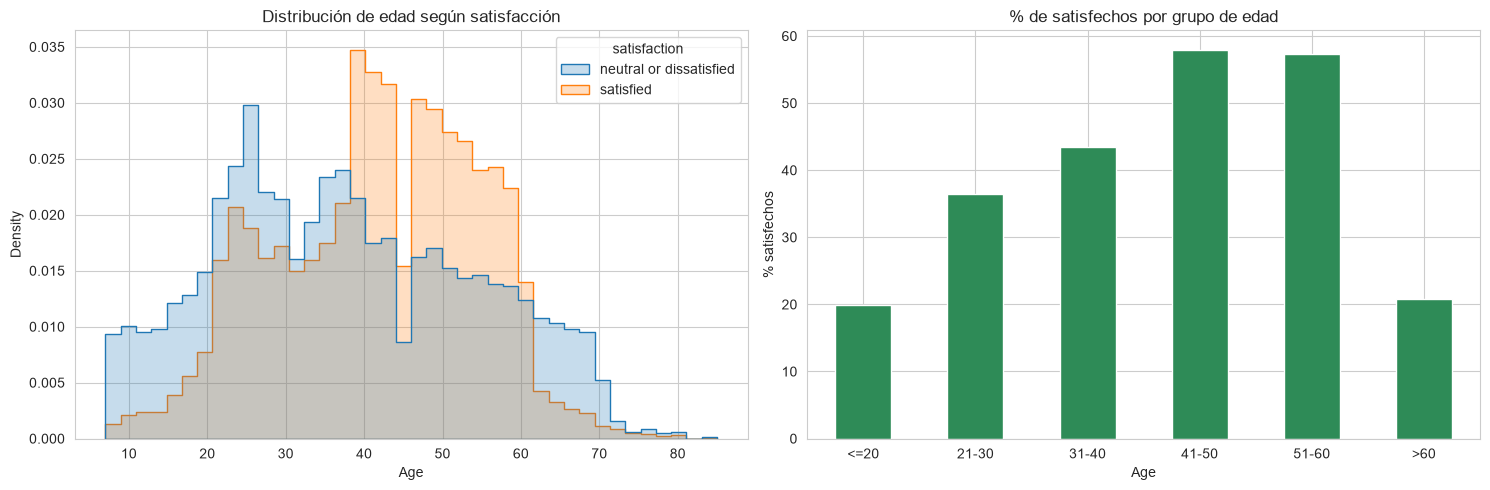

                           count  mean   std  min   25%   50%   75%   max
satisfaction                                                             
neutral or dissatisfied  73452.0  37.7  16.5  7.0  25.0  37.0  50.0  85.0
satisfied                56428.0  41.7  12.8  7.0  32.0  43.0  51.0  85.0


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(data=df, x='Age', hue='satisfaction', bins=40, element='step', stat='density',
             common_norm=False, ax=axes[0])
axes[0].set_title('Distribución de edad según satisfacción')

grupos_edad = pd.cut(df['Age'], bins=[0, 20, 30, 40, 50, 60, 90],
                     labels=['<=20', '21-30', '31-40', '41-50', '51-60', '>60'])
pct_sat_edad = (df['satisfaction'] == 'satisfied').groupby(grupos_edad, observed=True).mean() * 100
pct_sat_edad.plot(kind='bar', ax=axes[1], color='seagreen')
axes[1].set_title('% de satisfechos por grupo de edad')
axes[1].set_ylabel('% satisfechos')
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

print(df.groupby('satisfaction')['Age'].describe().round(1))

La edad sí tiene relación, pero **no es lineal**: la satisfacción sube con la edad hasta los 40-60 años (~58% satisfechos) y vuelve a caer en los mayores de 60 (21%) y en los menores de 20 (20%). Por eso la media casi no cambia entre grupos (41.7 contra 37.7 años) aunque la diferencia real es grande. Un coeficiente de correlación no capturaría bien esta forma de "U invertida".

Probablemente se explica en parte por el tipo de viaje: los de 40-60 son la edad típica de quien viaja por trabajo, en Business.

Para las demoras no sirve un boxplot, porque la mediana es 0 en los dos grupos y la caja queda aplastada. Es mejor agrupar las demoras en rangos y ver el % de satisfechos en cada uno:

                          vuelos  % satisfechos
Arrival Delay in Minutes                       
sin demora                 73146           47.4
1-15 min                   27176           41.2
16-60 min                  20470           35.9
1-3 horas                   7771           35.4
> 3 horas                   1317           36.4


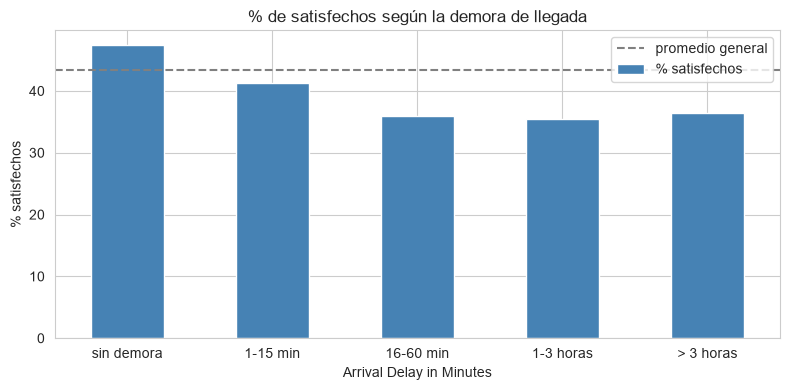

In [33]:
rangos_demora = pd.cut(df['Arrival Delay in Minutes'], bins=[-1, 0, 15, 60, 180, df['Arrival Delay in Minutes'].max()],
                       labels=['sin demora', '1-15 min', '16-60 min', '1-3 horas', '> 3 horas'])
tabla_demora = pd.DataFrame({
    'vuelos': rangos_demora.value_counts().sort_index(),
    '% satisfechos': ((df['satisfaction'] == 'satisfied').groupby(rangos_demora, observed=True).mean() * 100).round(1),
})
print(tabla_demora)

tabla_demora['% satisfechos'].plot(kind='bar', color='steelblue', figsize=(8, 4))
plt.axhline((df['satisfaction'] == 'satisfied').mean() * 100, color='gray', linestyle='--', label='promedio general')
plt.ylabel('% satisfechos')
plt.title('% de satisfechos según la demora de llegada')
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()

Las demoras sí bajan la satisfacción, pero menos de lo que se esperaría: sin demora hay 47% de satisfechos, y con demora de más de 15 minutos baja a ~36%. Lo curioso es que después de los 15 minutos ya no importa cuánto más se demore: 1 hora o más de 3 horas dan casi el mismo porcentaje. Parece que lo que molesta es que haya demora, no su duración. Esto lo probamos formalmente en la sección de hipótesis.

### Pairplot

Por último, un pairplot con las variables que más se relacionaron con la satisfacción, para ver varias relaciones a la vez. Usamos una muestra de 3,000 pasajeros:

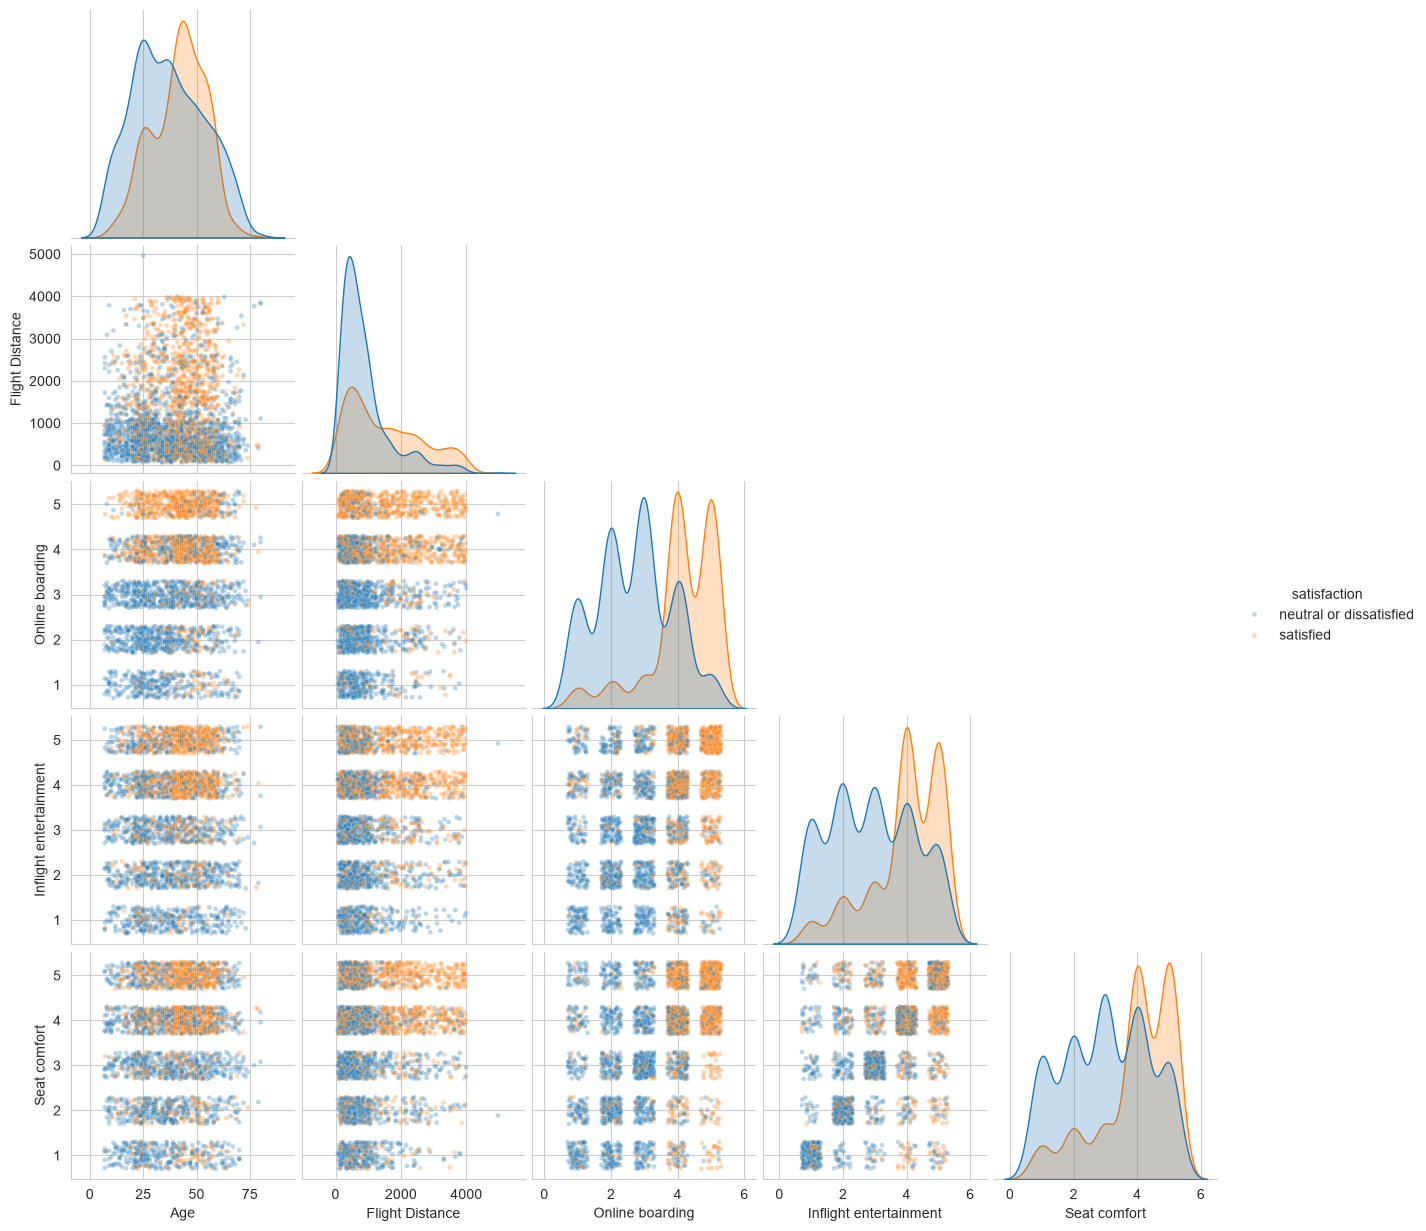

In [34]:
vars_pairplot = ['Age', 'Flight Distance', 'Online boarding', 'Inflight entertainment', 'Seat comfort']

muestra_pp = df[vars_pairplot + ['satisfaction']].copy()
muestra_pp[vars_pairplot[2:]] = muestra_pp[vars_pairplot[2:]].replace(0, np.nan)
muestra_pp = muestra_pp.dropna().sample(3000, random_state=42)

# las calificaciones son enteros y los puntos quedan uno encima de otro:
# les sumamos un ruido pequeño (jitter) solo para poder ver cuántos hay en cada valor
rng = np.random.default_rng(42)
for col in vars_pairplot[2:]:
    muestra_pp[col] = muestra_pp[col] + rng.uniform(-0.3, 0.3, len(muestra_pp))

sns.pairplot(muestra_pp, vars=vars_pairplot, hue='satisfaction', plot_kws={'alpha': 0.3, 's': 12},
             diag_kind='kde', corner=True)
plt.show()

- En la diagonal se ve lo mismo que antes: en `Online boarding` las curvas de satisfechos e insatisfechos están casi separadas (los satisfechos se concentran en 4-5), y en `Flight Distance` los satisfechos tienen una cola más larga hacia los vuelos largos.
- Entre las calificaciones se forma una grilla de nubes (una por combinación de notas, gracias al jitter), y el color muestra el patrón: la esquina de notas altas en `Online boarding` y `Inflight entertainment` es casi toda de satisfechos.
- Ninguna variable separa perfectamente los dos grupos por sí sola. La satisfacción depende de una combinación de factores, y eso justifica usar métodos multivariados como el PCA en la Fase 3.

## 8. Hipótesis y validación estadística

A partir de los patrones anteriores, planteamos:

- **H1:** el tipo de viaje influye en la satisfacción (negocios más satisfechos que personal).
- **H2:** la clase influye en la satisfacción (Business más satisfecho que Eco/Eco Plus).
- **H3:** la lealtad del cliente influye en la satisfacción.
- **H4:** `Type of Travel` y `Class` están relacionadas entre sí, así que su efecto sobre la satisfacción puede estar solapado — habría que separarlo con un modelo más adelante.

Probamos H1 con una prueba chi-cuadrado:

H0: no hay relación entre tipo de viaje y satisfacción.
H1: sí hay relación.

In [35]:
tabla_contingencia = pd.crosstab(df['Type of Travel'], df['satisfaction'])
print(tabla_contingencia)

chi2, p_valor, gl, esperado = chi2_contingency(tabla_contingencia)
print(f"\nChi-cuadrado: {chi2:.2f}")
print(f"Grados de libertad: {gl}")
print(f"Valor p: {p_valor}")

satisfaction     neutral or dissatisfied  satisfied
Type of Travel                                     
Business travel                    37337      52356
Personal Travel                    36115       4072

Chi-cuadrado: 26282.52
Grados de libertad: 1
Valor p: 0.0


El valor p sale prácticamente 0, mucho menor que 0.05, así que rechazamos H0: sí hay relación entre tipo de viaje y satisfacción, y no es casualidad.

Vale la pena aclarar algo: con una muestra tan grande (129,880 filas), el chi-cuadrado casi siempre va a salir significativo, incluso con diferencias chiquitas. Aquí no es el caso — la diferencia real (58% vs 10%) es enorme, así que el resultado importa tanto estadística como prácticamente.

### Tamaño del efecto: V de Cramér

Como dijimos, con 129,880 filas el valor p sale casi 0 aunque la relación sea débil. El valor p solo dice si hay relación, no qué tan fuerte es. Para medir la fuerza usamos la **V de Cramér**, que va de 0 (ninguna relación) a 1 (relación perfecta) y se calcula a partir del chi-cuadrado:

V = √( χ² / (n · (min(filas, columnas) − 1)) )

Como referencia, con tablas de 2 columnas: ~0.1 es un efecto pequeño, ~0.3 mediano y ≥0.5 grande.

Armamos una función que hace la prueba y calcula la V, para aplicarla a todas las hipótesis igual:

In [36]:
def prueba_chi2(var1, var2):
    tabla = pd.crosstab(df[var1], df[var2])
    chi2, p_valor, gl, _ = chi2_contingency(tabla)
    n = tabla.values.sum()
    v_cramer = np.sqrt(chi2 / (n * (min(tabla.shape) - 1)))
    return {'variables': f"{var1} vs {var2}", 'chi2': round(chi2, 1), 'gl': gl,
            'p_valor': p_valor, 'V_Cramer': round(v_cramer, 3)}

### H2 y H3: clase y lealtad vs satisfacción

- **H2** — H0: la clase y la satisfacción son independientes. H1: hay relación.
- **H3** — H0: el tipo de cliente (leal / no leal) y la satisfacción son independientes. H1: hay relación.

Incluimos también H1 (para comparar su V) y `Gender`, que en las tablas cruzadas no parecía importar:

In [37]:
resultados_chi2 = pd.DataFrame([
    prueba_chi2('Type of Travel', 'satisfaction'),   # H1
    prueba_chi2('Class', 'satisfaction'),            # H2
    prueba_chi2('Customer Type', 'satisfaction'),    # H3
    prueba_chi2('Gender', 'satisfaction'),           # control
]).set_index('variables')
resultados_chi2

,chi2,gl,p_valor,V_Cramer
variables,,,,
Type of Travel vs satisfaction,26282.5,1,0.000000,0.450
Class vs satisfaction,32906.2,2,0.000000,0.503
Customer Type vs satisfaction,4493.2,1,0.000000,0.186
Gender vs satisfaction,16.4,1,0.000053,0.011


- **H2 (clase):** p ≈ 0 → rechazamos H0. V = 0.50, un efecto **grande**. Es la variable categórica más relacionada con la satisfacción, incluso un poco más que el tipo de viaje (V = 0.45). Mirando solo los porcentajes parecía que el tipo de viaje ganaba (58% vs 10%), pero la V tiene en cuenta toda la tabla y cuánta gente hay en cada grupo.
- **H3 (lealtad):** p ≈ 0 → rechazamos H0. V = 0.19, un efecto **pequeño-mediano**. Influye, pero bastante menos que las otras dos.
- **Gender:** p = 0.00005, que también es "significativo" (< 0.05), pero V = 0.01, prácticamente cero. Es el mejor ejemplo de lo que decíamos: con una muestra tan grande hasta una diferencia de 1 punto (57% vs 56%) sale significativa. Por eso no basta con mirar el valor p: la V muestra que el género en la práctica no importa.

### H4: Type of Travel y Class están relacionadas

H0: el tipo de viaje y la clase son independientes. H1: están relacionadas.

In [38]:
pd.DataFrame([prueba_chi2('Type of Travel', 'Class')]).set_index('variables')

,chi2,gl,p_valor,V_Cramer
variables,,,,
Type of Travel vs Class,39886.2,2,0.0,0.554


p ≈ 0 y V = 0.55, la relación más fuerte de todas las que probamos. Rechazamos H0: el tipo de viaje y la clase están muy ligadas, lo que confirma lo que vimos en la tabla cruzada (66% de los viajes de negocios son en Business, 82% de los personales en Eco).

Entonces, ¿cuál de las dos explica la satisfacción? Para separarlas sin un modelo, miramos el % de satisfechos en cada combinación, es decir, comparamos clases **dentro** de un mismo tipo de viaje:

Class            Business   Eco  Eco Plus
Type of Travel                           
Business travel      72.0  29.9      39.3
Personal Travel      11.7  10.2       8.7


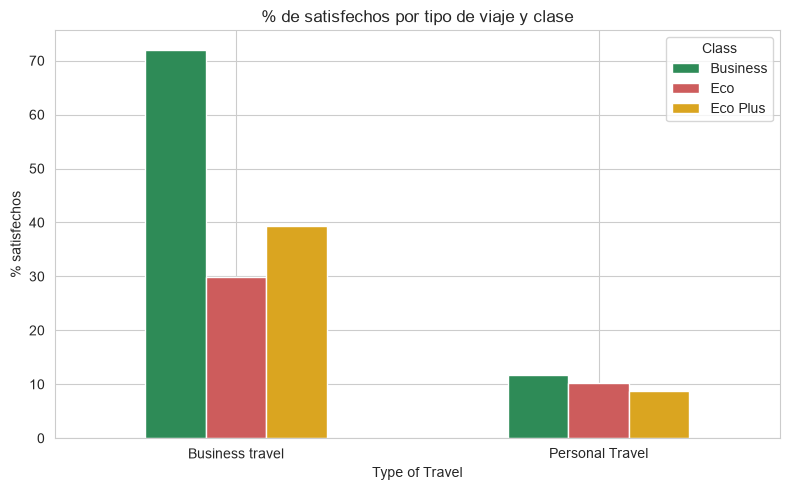

In [39]:
pct_satisfechos = pd.pivot_table(df.assign(satisfecho=(df['satisfaction'] == 'satisfied') * 100),
                                 index='Type of Travel', columns='Class', values='satisfecho', aggfunc='mean').round(1)
print(pct_satisfechos)

pct_satisfechos.plot(kind='bar', figsize=(8, 5), color=['seagreen', 'indianred', 'goldenrod'])
plt.ylabel('% satisfechos')
plt.title('% de satisfechos por tipo de viaje y clase')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Esta tabla es de lo más interesante del análisis:

- **Viaje personal:** la clase **no cambia nada**. Ya sea en Business, Eco o Eco Plus, solo ~10% están satisfechos. Pagar Business no hace más feliz a quien viaja por motivos personales.
- **Viaje de negocios:** la clase **sí importa mucho**: 72% de satisfechos en Business contra 30% en Eco.

O sea que no son dos efectos que se suman. La clase solo marca diferencia para quienes viajan por trabajo, y quienes viajan por motivos personales están insatisfechos en cualquier clase. Esto se llama **interacción** entre variables, y un modelo que las use por separado podría no capturarla.

### H5: los insatisfechos tuvieron más demora

Esta hipótesis es con una variable numérica, así que no sirve el chi-cuadrado. Tampoco podemos usar la prueba t, porque supone datos más o menos normales y los delays tienen skewness ~6.8. Usamos la prueba **Mann-Whitney U**, que no supone ninguna distribución: compara los rangos de los dos grupos (si al ordenar todos los datos, los de un grupo tienden a quedar más arriba que los del otro).

- H0: la demora de los insatisfechos no es mayor que la de los satisfechos.
- H1: los insatisfechos tienden a tener más demora (prueba de una cola: `alternative='greater'`).

Para medir el tamaño del efecto calculamos la **correlación biserial de rangos** (r = 2U / (n₁·n₂) − 1), que va de −1 a 1 y se lee como una correlación.

In [40]:
insatisfechos = df['satisfaction'] == 'neutral or dissatisfied'

resultados_mw = []
for col in ['Departure Delay in Minutes', 'Arrival Delay in Minutes']:
    x = df.loc[insatisfechos, col]
    y = df.loc[~insatisfechos, col]
    U, p_valor = stats.mannwhitneyu(x, y, alternative='greater')
    resultados_mw.append({
        'variable': col,
        'media insatisfechos': round(x.mean(), 1),
        'media satisfechos': round(y.mean(), 1),
        '% con demora (insatisf.)': round((x > 0).mean() * 100, 1),
        '% con demora (satisf.)': round((y > 0).mean() * 100, 1),
        'U': U,
        'p_valor': p_valor,
        'r_biserial': round(2 * U / (len(x) * len(y)) - 1, 3),
    })
pd.DataFrame(resultados_mw).set_index('variable')

,media insatisfechos,media satisfechos,% con demora (insatisf.),% con demora (satisf.),U,p_valor,r_biserial
variable,,,,,,,
Departure Delay in Minutes,16.4,12.5,46.0,40.3,2.223026e+09,1.550914e-136,0.073
Arrival Delay in Minutes,17.0,12.5,47.6,38.6,2.291686e+09,3.760669e-286,0.106


- En las dos variables p ≈ 0 (del orden de 10⁻¹³⁶ y 10⁻²⁸⁶), así que rechazamos H0: los insatisfechos sí tuvieron más demora, en promedio 17 minutos de llegada contra 12.5, y el 48% tuvo alguna demora contra el 39% de los satisfechos.
- Pero el tamaño del efecto es **pequeño**: r = 0.07 en la salida y 0.11 en la llegada. Es el mismo caso del género, a menor escala: la diferencia es real pero explica poco de la satisfacción.
- La demora de **llegada** pesa un poco más que la de salida. Tiene sentido: al pasajero le importa a qué hora llega, y un avión que sale tarde puede recuperar tiempo en el aire.

Esto confirma lo que vimos en los gráficos: la demora influye, pero mucho menos que la clase, el tipo de viaje o las calificaciones del servicio (`Online boarding`, entretenimiento, asiento).

### Resumen de las hipótesis

| Hipótesis | Prueba | p-valor | Tamaño del efecto | Resultado |
|---|---|---|---|---|
| H1: tipo de viaje → satisfacción | Chi-cuadrado | ≈ 0 | V = 0.45 (grande) | Se rechaza H0 |
| H2: clase → satisfacción | Chi-cuadrado | ≈ 0 | V = 0.50 (grande) | Se rechaza H0 |
| H3: lealtad → satisfacción | Chi-cuadrado | ≈ 0 | V = 0.19 (pequeño-mediano) | Se rechaza H0 |
| H4: tipo de viaje ↔ clase | Chi-cuadrado | ≈ 0 | V = 0.55 (grande) | Se rechaza H0 (con interacción) |
| H5: más demora en insatisfechos | Mann-Whitney U | ≈ 0 | r = 0.07 – 0.11 (pequeño) | Se rechaza H0, efecto débil |
| (control) género → satisfacción | Chi-cuadrado | 0.00005 | V = 0.01 (nulo) | Significativo pero irrelevante |

## 9. Conclusiones

**Insights principales**
1. **La clase y el tipo de viaje son los factores categóricos más asociados con la satisfacción** (V de Cramér = 0.50 y 0.45). Business alcanza 69% de satisfechos frente a 19% en Eco; los viajes de negocios 58% frente a 10% en los personales.
2. **Existe interacción entre ambas variables** (H4, V = 0.55): en viajes personales la clase no modifica la satisfacción (~10% en cualquier clase), mientras que en viajes de negocios pasa de 30% en Eco a 72% en Business.
3. **`Online boarding` es la calificación que más diferencia a los grupos** (4.15 en satisfechos vs. 2.71 en insatisfechos), seguida de `Inflight entertainment`, `Inflight wifi service` y `Seat comfort`. `Gate location` y `Departure/Arrival time convenient` no presentan diferencias.
4. **Las 14 calificaciones se agrupan en 3–4 dimensiones** (servicios digitales, comodidad a bordo y atención del personal), lo que indica redundancia aprovechable con PCA.
5. **La edad tiene una relación no lineal** con la satisfacción (forma de U invertida): ~58% de satisfechos entre 40 y 60 años frente a ~20% en menores de 20 y mayores de 60.
6. **Las demoras reducen la satisfacción, pero con un efecto débil** (Mann-Whitney, r = 0.07–0.11): de 47% de satisfechos sin demora a ~36% con más de 15 minutos, sin mayor efecto por la duración.
7. **La lealtad influye con un efecto pequeño-mediano** (V = 0.19) y el **género no es relevante** (V = 0.01, significativo solo por el tamaño de la muestra).
8. **Los delays presentan sesgo extremo** (skewness ≈ 6.8). Los outliers del IQR (~14%) corresponden a demoras reales y se conservan; `log1p` reduce el sesgo a menos de 1. La correlación entre ambos delays es de 0.96 (Pearson) y 0.74 (Spearman).

**Problemas de calidad detectados**
- Columna `Unnamed: 0` sin información (eliminada).
- 393 faltantes en `Arrival Delay in Minutes` (0.3%), imputados con la mediana; dada la correlación con `Departure Delay in Minutes`, es preferible imputar con esta última.
- Ceros ocultos en las calificaciones (10,313 filas): representan "no respondió" y no son aleatorios (99.7% de satisfechos entre quienes dejaron el wifi en 0).
- Sin filas ni `id` duplicados.

**Líneas de análisis para fases posteriores**
- Incorporar indicadores de "no respondió" para las preguntas con más ceros e imputar `Arrival Delay` con `Departure Delay` (aplicado en `03_preprocesamiento.ipynb`).
- Modelar la interacción entre `Type of Travel` y `Class` y la relación no lineal de la edad.
- Evaluar la importancia relativa de las calificaciones en un modelo de clasificación.